# EDA: PCA Anlaysis and Spatial Clustering 

In [2]:
% load data
addpath('matlab','data')
load('calcium_data.mat')
load('stimuli_info.mat')
load ('data_stimsorted.mat')
load('ROI_positions.mat')

In [126]:
%Variables
thrld = 0.25;
fov = 4; % 1 of 8 FOV
tbin = 1; % 1 second time bin
num_rois = numel(fieldnames(dat_sorted{fov}.deNoise_dff));
stimulus = {'e3', 'e2', 'e1', 'd3', 'd2', 'd1', 'c3', 'c2', 'c1', 'blank'};

## 1. Revise Time Bin

Below are the dF/F traces for ROI132 in FOV1, which is one of the most active cells. The peak of the dF/F post stimulus onset lies outside current time bin. Could be better to shift window by 2 frames 

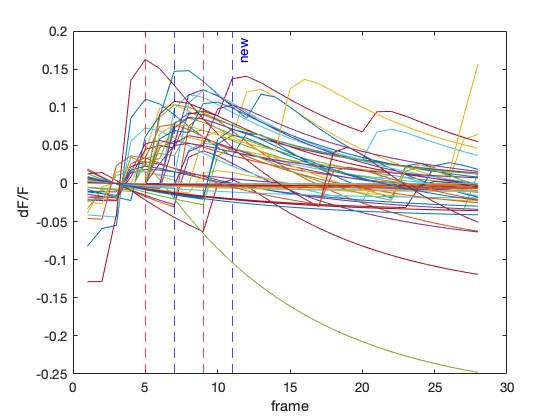

In [7]:
% Plot current time bin window 

stim_onset = 5;
frameRate = 7.4811;
t_end = stim_onset + round(tbin*frameRate);

dff_stim = dat_sorted{fov}.deNoise_dff.ROI132.d2;
plot(dff_stim.')
xline(stim_onset,'--r');
xline(t_end, '--r');
xline(stim_onset+2,'--b');
xline(t_end+2, '--b', 'new');
xlabel('frame')
ylabel('dF/F')

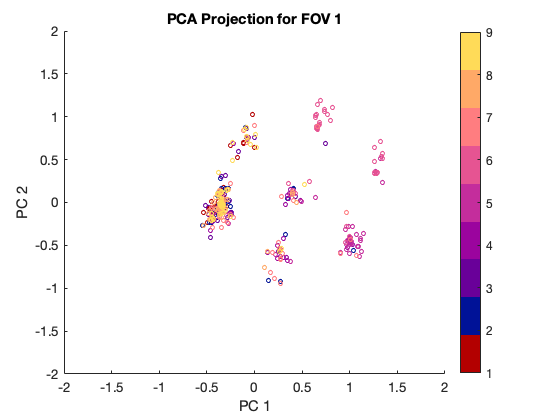

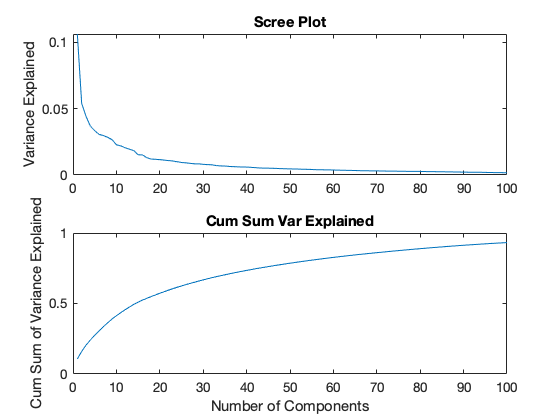

In [138]:
%Run PCA on both Arrays
t_start = 8;
frameRate = 7.4811;
t_end = t_start + round(tbin*frameRate);

[stim_PA, stim_label] = get_stim_PA(dat_sorted,fov,thrld,t_start,tbin);
[PCA_allstim.coeff,PCA_allstim.score,PCA_allstim.latent] = pca(stim_PA, 'Centered', true);
% stim_PA_zscore = zscore(stim_PA);
% [PCA_allstim.coeff,PCA_allstim.score,PCA_allstim.latent] = pca(stim_PA_zscore, 'Centered', false);


figure(1)
plot_PCAscores(PCA_allstim.score(:,1),PCA_allstim.score(:,2), stim_label, 'PCA Projection for FOV 1')

% Variance Explained 
figure(2)
var_exp = plot_scree(PCA_allstim.latent/sum(PCA_allstim.latent));

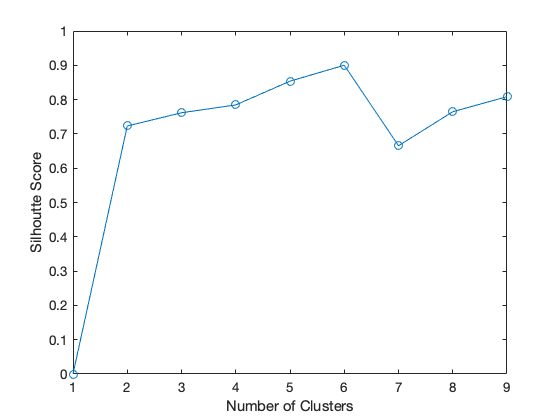

In [139]:
% Silhoutte Analysis to determine cluster number
s_score = zeros(9,1);
for cluster_num = 1:9
    cluster_lbls = kmeans(PCA_allstim.score(:,1:2),cluster_num, 'Distance', 'sqeuclidean');
    s = silhouette(PCA_allstim.score(:,1:2),cluster_lbls);
    s_score(cluster_num) = mean(s);
end

s_score(1) = 0;
plot(s_score, '-o')
xlabel('Number of Clusters')
ylabel('Silhoutte Score')

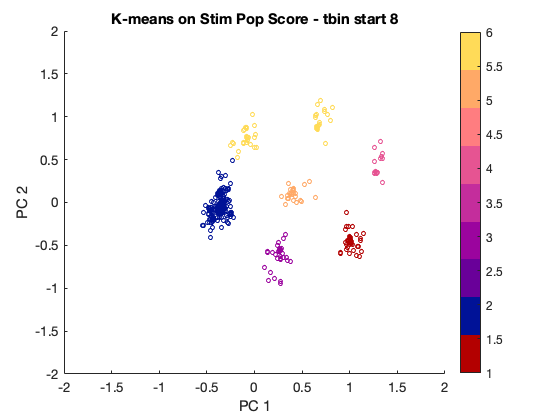

In [140]:
%K-means on PC Data
cluster_num = find(s_score == max(s_score));
[cluster_lbls,centroid_locs,sumd] = kmeans(PCA_allstim.score(:,1:2),cluster_num, 'Distance', 'sqeuclidean');
figure(2)
plot_PCA(PCA_allstim.score, cluster_lbls, ['K-means on Stim Pop Score - tbin start ',num2str(t_start)])

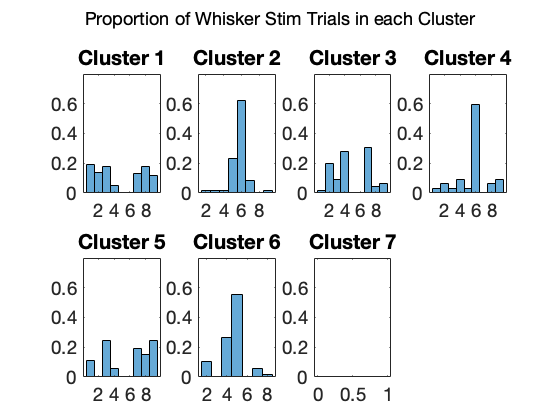

In [131]:
% Proportion of all whisker stim trials contained in each cluster
whiskers = {'e3', 'e2', 'e1', 'd3', 'd2', 'd1', 'c3', 'c2', 'c1'};
x = categorical(whiskers);
x = reordercats(x, whiskers);
cluster_size = [];

for cluster = 1:7
    idx = find(cluster_lbls == cluster); % find index position of cluster
    cluster_stim = stim_label(idx); % retrieve which whisker was deflected in that trial 
    cluster_size = [cluster_size; size(cluster_stim)];
    subplot(2,4,cluster)
    histogram(cluster_stim, 'Normalization', 'probability') % plot histogram 
    ylim([0,0.8])
    plt_title = ['Cluster ',num2str(cluster)];
    set(gca,'FontSize', 14)
    title(plt_title)
end
set(gca,'FontSize', 14)
sgtitle('Proportion of Whisker Stim Trials in each Cluster')



Whisker 5 = D2
Whisker 6 = D1

## 2. Barrel Organization

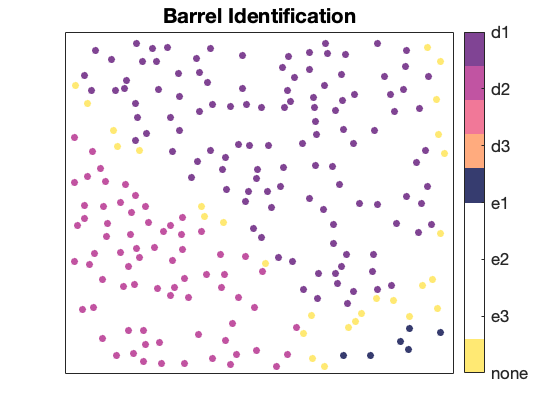

In [12]:
%Plot average dF/F on map of ROIs with barrel columns specified

% Get ROI Positions 
x_pst = zeros(numel(fields(ROI_position{fov}.ROI_centroids)),1);
y_pst = zeros(numel(fields(ROI_position{fov}.ROI_centroids)),1);
% x_pst = zeros(num_rois,1);
% y_pst = zeros(num_rois,1);
for i = 1:numel(fields(ROI_position{fov}.ROI_centroids))
    roi = ['ROI', num2str(i)];
    x_pst(i) = ROI_position{fov}.ROI_centroids.(roi)(1);
    y_pst(i) = ROI_position{fov}.ROI_centroids.(roi)(2);
end

column_identity = get_barrel_identity(ROI_position, fov); % get column barrel identities 
figure(1)
plot_clusteronROIS(x_pst, y_pst, column_identity,'Barrel Identification',30)
cmap_column = [0.502,0.267,0.580;
          0.757,0.329,0.635;
          0.945,0.471,0.596;
          1.000,0.671,0.494;
          0.212,0.235,0.435;
          1.000,1.000,1.000;
          1.000,1.000,1.000;
          1.000,1.000,1.000;
          1.000,1.000,1.000;
          1.000,0.914,0.451];
caxis('auto');
colormap(flipud(cmap_column));
bcolumns = {'none','e3', 'e2', 'e1', 'd3', 'd2', 'd1', 'c3', 'c2', 'c1'};
colorbar('TickLabels', bcolumns)
set(gca,'FontSize', 14)


## 3. Average dF/F for each Whisker Trial Type with new t_start

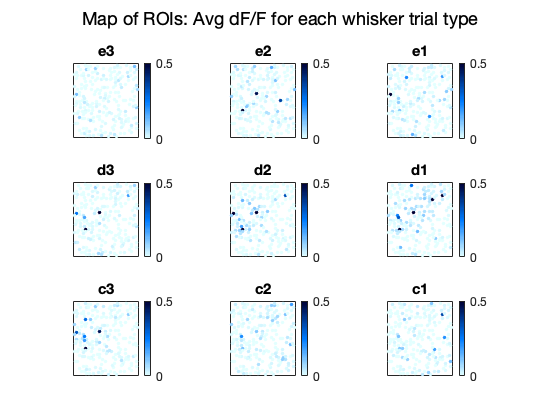

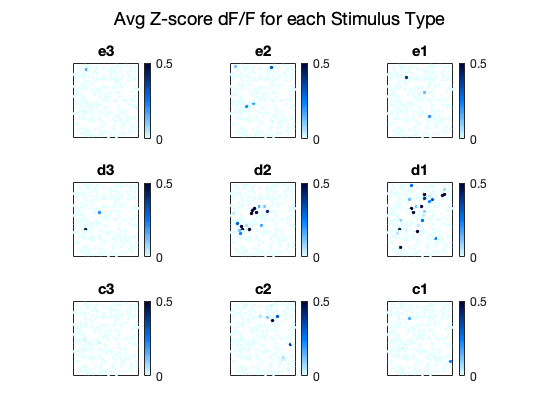

In [15]:
%% Average dFF for each whisker trial type - non-normalized 

%intialize
ROI_maxdff4stim = zeros(num_rois,length(stimulus)-1);
ROI_maxdff4stim_norm = zeros(num_rois,length(stimulus)-1);

% get max dF/F
for r = 1:num_rois
    roi = ['ROI', num2str(r)];
    
    %get z-score from denoised dF/F - all 15 movies 
    all_movies = [];
    for m  = 1:numel(fields(data{fov}.ROI1))
        mname = ['movie_',num2str(m)];
        all_movies = [all_movies, data{fov}.(roi).(mname).deNoise_dff]; 
    end
    [~, mu, sigma] = zscore(all_movies);
    
    %get df/f
    for stim_num = 1: length(stimulus)-1
        stim = stimulus{stim_num};
        dff_stim = dat_sorted{fov}.deNoise_dff.(roi).(stim);
        ROI_maxdff4stim_norm(r, stim_num) = mean(max((dff_stim(:,t_start:t_end)-mu)/sigma,[],2));
        ROI_maxdff4stim(r, stim_num) = mean(max(dff_stim(:,t_start:t_end),[],2));
    end
end

%Plot average dF/F for each whisker trial type on map of ROIs
figure(1)
for stim = 1:length(stimulus)-1
    subplot(3,3,stim)
    plot_clusteronROIS(x_pst, y_pst, ROI_maxdff4stim(:,stim), stimulus{stim},8)
end
sgtitle('Map of ROIs: Avg dF/F for each whisker trial type')

%Plot average dF/F for whisker trial type on map of ROIs - Zscore
figure(2)
for stim = 1:length(stimulus)-1
    subplot(3,3,stim)
    set(gca,'FontSize', 14)
    plot_clusteronROIS(x_pst, y_pst, ROI_maxdff4stim_norm(:,stim), stimulus{stim},8)
end
sgtitle('Avg Z-score dF/F for each Stimulus Type')

## 4. Average dF/F for Clustered Trials:  t_start = 8

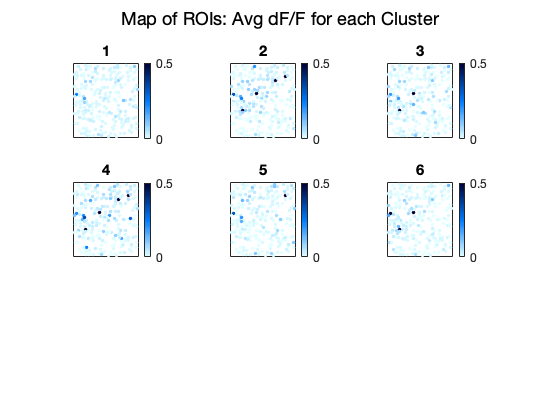

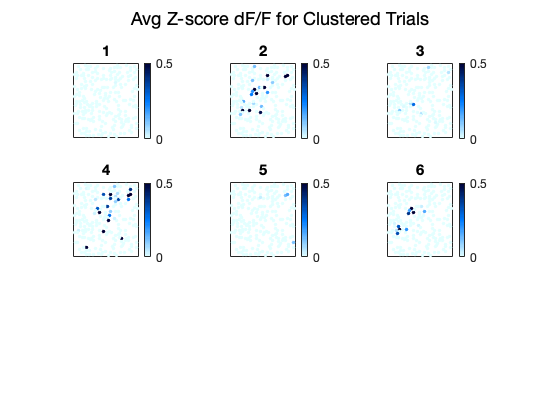

In [137]:
% Get dFF for all trials within cluster 
cluster_info = cluster_idxs(dat_sorted,fov, cluster_lbls, stim_label);
[cluster_info,cluster_dff_avg, cluster_dff_avg_norm] = get_dff_cluster(data, dat_sorted, fov, cluster_info, tbin);     

%Plot average dF/F on map of ROIs
figure(1)
for clust = 1:length(cluster_info)
    subplot(3,3,clust)
    plot_clusteronROIS(x_pst, y_pst, cluster_dff_avg(:,clust), [num2str(clust)],8)
end
sgtitle('Map of ROIs: Avg dF/F for each Cluster')

% Z-score dF/F
figure(2)
for clust = 1:length(cluster_info)
    subplot(3,3,clust)
    plot_clusteronROIS(x_pst, y_pst, cluster_dff_avg_norm(:,clust), [num2str(clust)],8)
end
sgtitle('Avg Z-score dF/F for Clustered Trials')

## 5. Whisker Tuning for Cells in PCA Identified Clusters
Whisker receptive fields for spatially clustered ROIS after PCA

Error using subplot (line 332)
Index exceeds number of subplots.



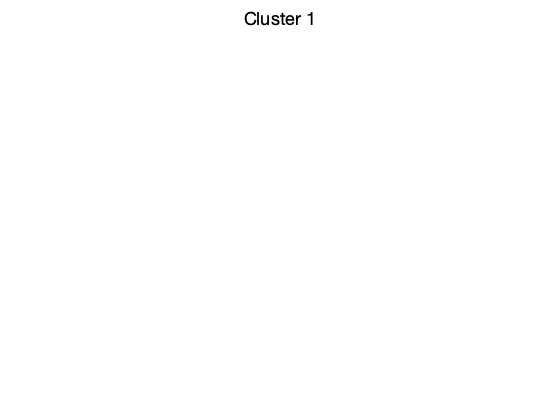

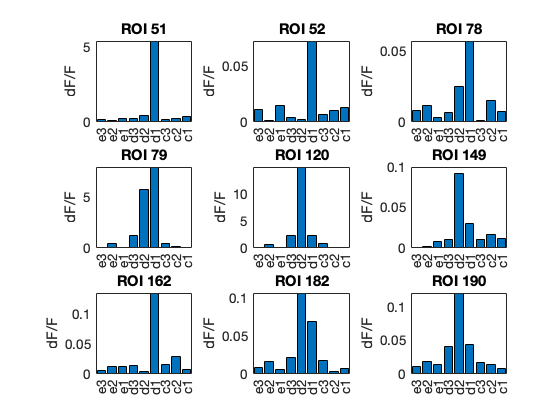

In [133]:
% Get dF/F for Cells within Cluster for each whisker stimulus type 
cutoff = 0.2;
spatial_clusters = get_spatial_cluster(dat_sorted, data, cluster_dff_avg_norm, cutoff, cluster_num, fov, t_start, tbin);

%Plot whisker tuning for each ROI in each cluster for all clusters  

whiskers = {'e3', 'e2', 'e1', 'd3', 'd2', 'd1', 'c3', 'c2', 'c1'};
x = categorical(whiskers);
x = reordercats(x, whiskers);

for clusters = 1: length(spatial_clusters)
    y = zscore(spatial_clusters{clusters}.dff_max,[],2);
    figure(clusters)
    for rois = 1: size(spatial_clusters{clusters}.dff_max,1)
        subplot(3,3,rois)
%         hold on 
        bar(x,spatial_clusters{clusters}.dff_max(rois,:))
%         er = errorbar(x, spatial_clusters{clusters}.dff_max(rois,:),spatial_clusters{clust}.dff_max_std(rois,:));
%         er.Color = [0 0 0];                            
%         er.LineStyle = 'none'; 
        ylabel('dF/F')
        title(['ROI ', num2str(spatial_clusters{clusters}.rois(rois))])
%         hold off
    end
    sgtitle(['Cluster ', num2str(clusters)])
end


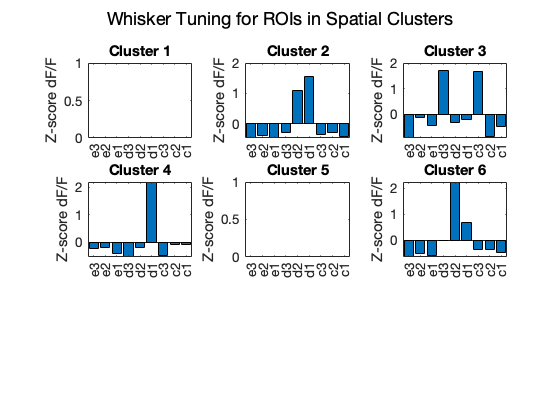

In [134]:
% Mean Whisker Receptive Field for ROIs in Cluster

for clusters = 1: length(spatial_clusters)
    y = zscore(spatial_clusters{clusters}.dff_max,[],2);
    whisk_resp_avg = mean(y,1);
    subplot(3,3,clusters)
    bar(x,whisk_resp_avg)
    ylabel('Z-score dF/F')
    title(['Cluster ', num2str(clusters)])
end
sgtitle('Whisker Tuning for ROIs in Spatial Clusters')

## 5. Tuning of Cells strongly weighted in PC1 and PC2

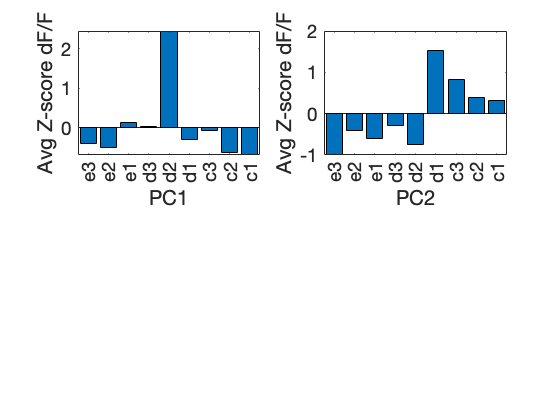

In [118]:
y = zscore(PC_weights{1}.dff_max,[],2);
whisk_resp_avg_PC1 = mean(y(4:5,:),1);
subplot(2,2,1)
bar(x,whisk_resp_avg_PC1)
set(gca,'FontSize', 14)
ylabel('Avg Z-score dF/F')
xlabel('PC1')

y = zscore(PC_weights{2}.dff_max,[],2);
whisk_resp_avg_PC2 = mean(y(4:6,:),1);
subplot(2,2,2)
bar(x,whisk_resp_avg_PC2)
ylabel('Avg Z-score dF/F')
xlabel('PC2')
set(gca,'FontSize', 14)

## PC Weight Analysis

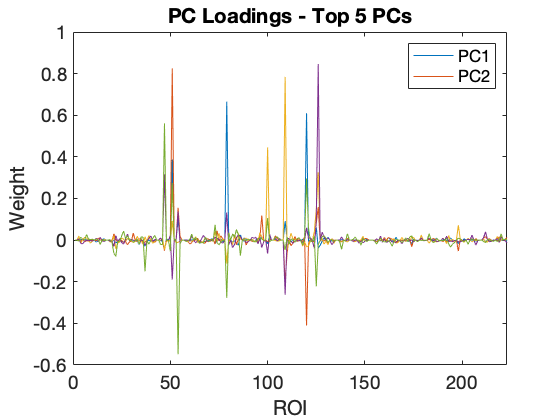

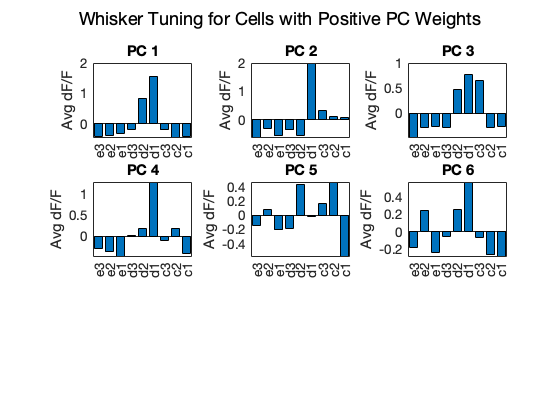

In [135]:
% Check PC weights 

% plot_ROIlabel(x_pst, y_pst, PCA_allstim.coeff(:,PC), ['Map of ROIs with PC ', num2str(PC), ' Weights'])
figure(1)
plot(PCA_allstim.coeff(:,1:5))
xlim([0,223])
set(gca,'FontSize', 14)
xlabel('ROI')
ylabel('Weight')
title('PC Loadings - Top 5 PCs')
legend('PC1', 'PC2')

cutoff = 0.05;
for PC = 1:6 
    PC_weights{PC}.rois = find(PCA_allstim.coeff(:,PC) > cutoff);
    PC_weights{PC}.dff_max = zeros(length(PC_weights{PC}.rois),9);
    for nrois = 1:length(PC_weights{PC}.rois)
        roi = ['ROI', num2str(PC_weights{PC}.rois(nrois))];
        for stim_num = 1:length(stimulus)-1
            stim = stimulus{stim_num};
            dff_stim = dat_sorted{fov}.deNoise_dff.(roi).(stim);
            PC_weights{PC}.dff_max(nrois,stim_num) = mean(max(dff_stim(:,t_start:t_end),[],2));
        end
    end 
end

%Plot whisker tuning for each ROI weighted strongly in first few PCs  
figure(2)
whiskers = {'e3', 'e2', 'e1', 'd3', 'd2', 'd1', 'c3', 'c2', 'c1'};
x = categorical(whiskers);
x = reordercats(x, whiskers);

% Mean Whisker Receptive Field for ROIs in Cluster

for PC = 1:6
    y = zscore(PC_weights{PC}.dff_max,[],2);
    whisk_resp_avg = mean(y,1);
    subplot(3,3,PC)
    bar(x,whisk_resp_avg)
    ylabel('Avg dF/F')
    title(['PC ', num2str(PC)])
end
sgtitle('Whisker Tuning for Cells with Positive PC Weights')

### Observations:

Clusters with large PC2 values contain cells that are preferentially tuned to d1. 

PC2 is the d1 cluster and PC1 is mixed D1 and D2

## 6. Other: Look at PC Projections

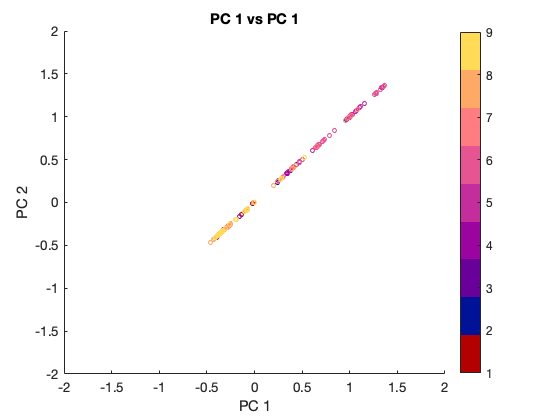

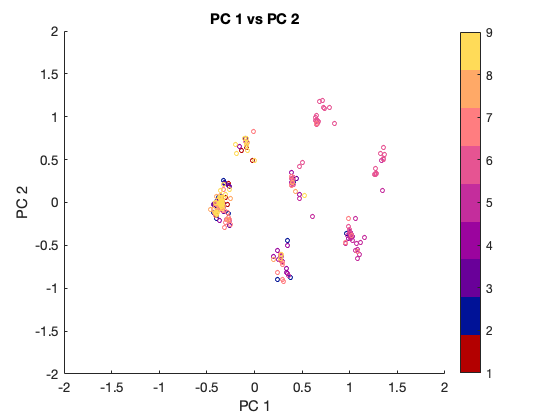

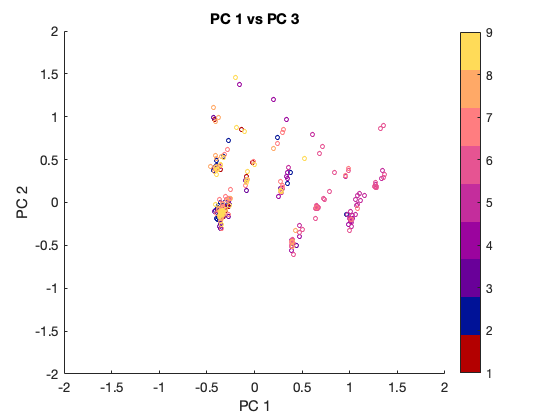

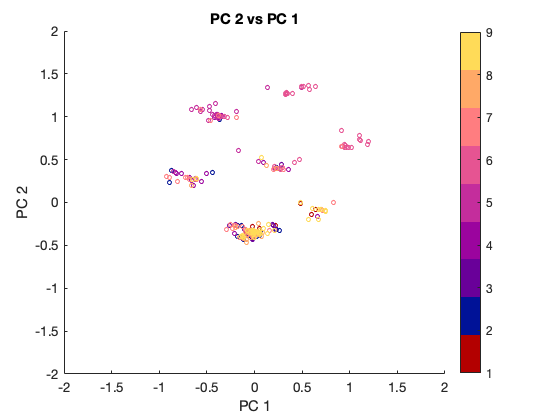

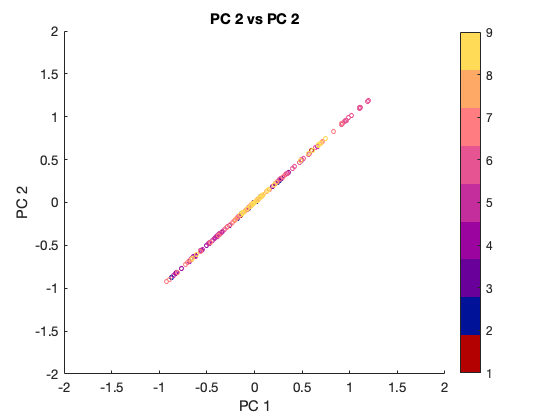

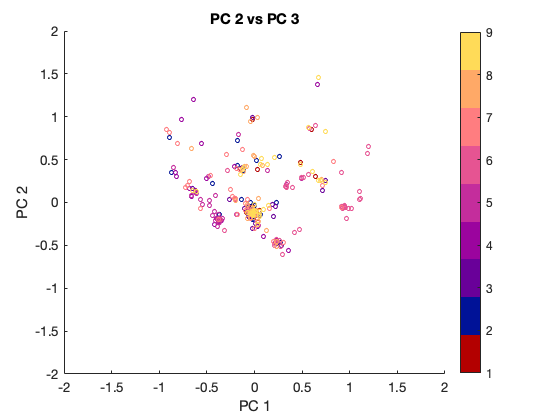

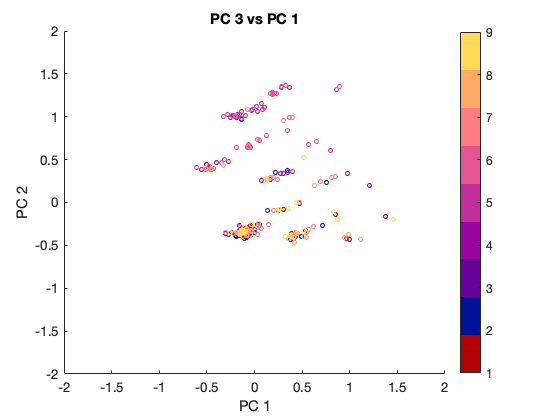

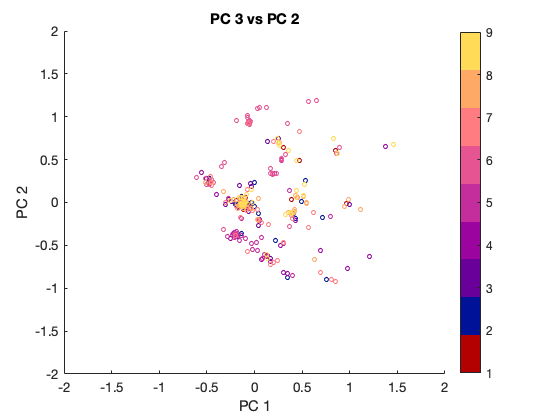

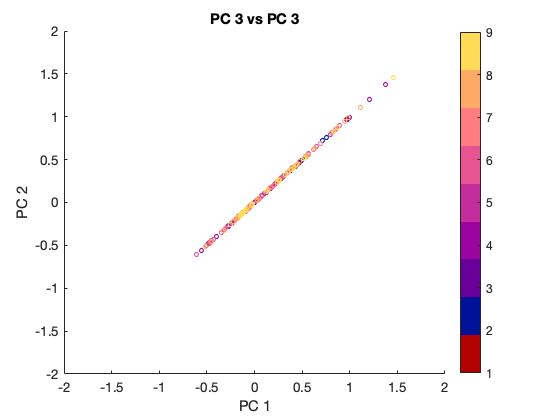

In [333]:
% Look at Other PC Projections
n = 0;
for i = 1:3
    for j = 1:3
    n = n+1;
    figure(n)
    plot_PCAscores(PCA_allstim.score(:,i),PCA_allstim.score(:,j), stim_label, ['PC ', num2str(i), ' vs PC ', num2str(j)])
    end
end

## Conclusions
- PCA gives fairly inconsistent results - unstable : changing t_start by 1 frame changes clusters considerably 
- Loading values are mostly zero, few ROIs have positive weights > 0.1 and are shared among PCs 

## 7. Other: Project K-means cluster on ROI positions 


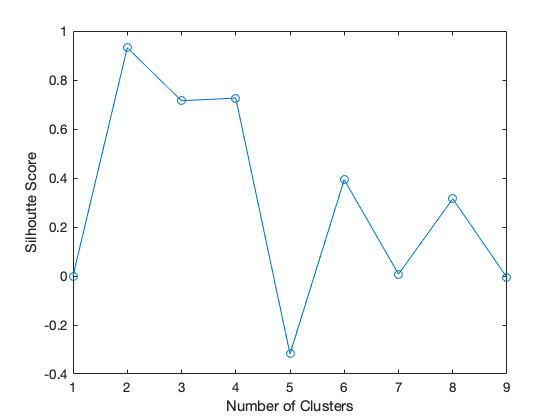

In [334]:
% Silhoutte Analysis to determine cluster number - cluster ROIs
s_score = zeros(9,1);
for cluster_num = 1:9
    cluster_lbls = kmeans(stim_PA.',cluster_num, 'Distance', 'sqeuclidean');
    s = silhouette(stim_PA.',cluster_lbls);
    s_score(cluster_num) = mean(s);
end

s_score(1) = 0;
plot(s_score, '-o')
xlabel('Number of Clusters')
ylabel('Silhoutte Score')

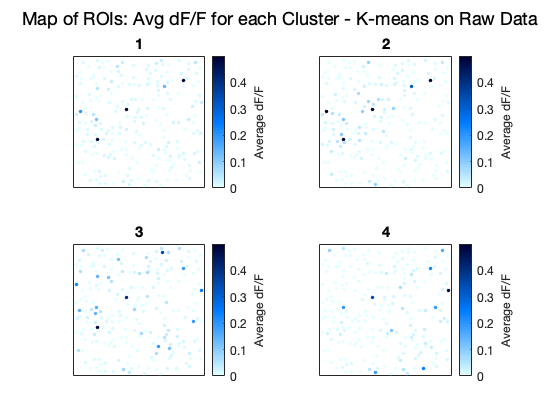

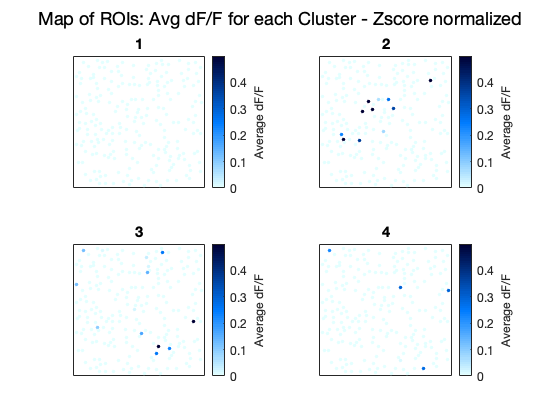

In [335]:
% K-means on Raw Data - Look for where centroids map on ROI Map 
cluster_num = 4;
[cluster_lbls_raw,centroid_locs_raw,sumd_raw] = kmeans(stim_PA,cluster_num, 'Distance', 'cityblock');

% Get dFF for all trials within cluster 
cluster_info_raw = cluster_idxs(dat_sorted,fov, cluster_lbls_raw, stim_label);
[cluster_info_raw,cluster_dff_avg_raw, cluster_dff_avg_raw_norm] = get_dff_cluster(data,dat_sorted, fov, cluster_info_raw, tbin);     

%Plot average dF/F on map of ROIs
for clust = 1:length(cluster_info_raw)
    subplot(2,2,clust)
    plot_clusteronROIS(x_pst, y_pst, cluster_dff_avg_raw(:,clust), [num2str(clust)],8)
end
sgtitle('Map of ROIs: Avg dF/F for each Cluster - K-means on Raw Data')

% Z-score dF/F
figure(2)
for clust = 1:length(cluster_info_raw)
    subplot(2,2,clust)
    plot_clusteronROIS(x_pst, y_pst, cluster_dff_avg_raw_norm(:,clust), [num2str(clust)],8)
end
sgtitle('Map of ROIs: Avg dF/F for each Cluster - Zscore normalized')

Clustering based on the "raw" population array leads to unstable results 

## Next Steps

- Use the spike probability to estimate firing rate instead of spike / no spike 


# OTHER: Figures for Presentation

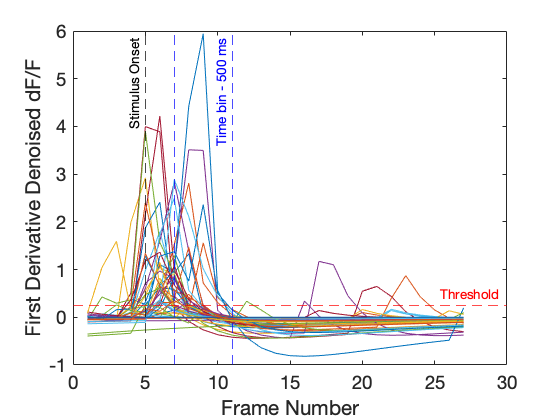

In [110]:
% Graph for Presentation

stim_onset = 5;
frameRate = 7.4811;
t_end = stim_onset + round(tbin*frameRate);

dff_stim = dat_sorted{fov}.deNoise_dff.ROI120.d1;
dff_deriv = diff(dff_stim,1,2);
plot(dff_deriv.')
set(gca,'FontSize', 14)
xline(stim_onset,'--k','Stimulus Onset','LabelHorizontalAlignment', 'left','LabelVerticalAlignment', 'top');
xline(stim_onset+2,'--b');
xline(t_end+2, '--b', 'Time bin - 500 ms', 'LabelHorizontalAlignment', 'left','LabelVerticalAlignment', 'top');
yline(thrld, '--r', 'Threshold');
xlabel('Frame Number')
ylabel('First Derivative Denoised dF/F')


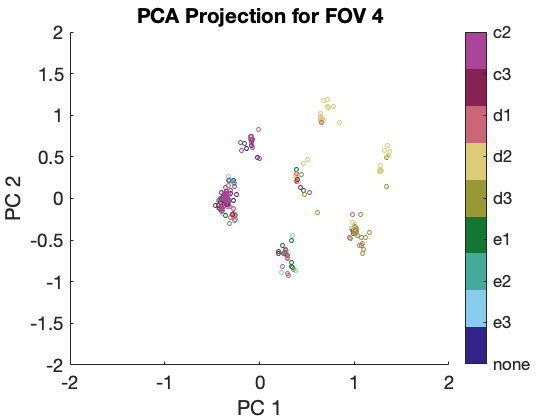

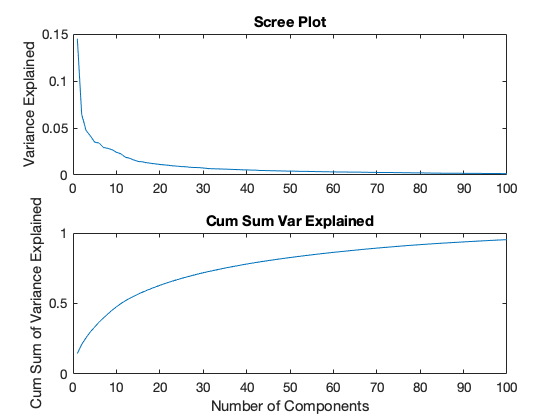

In [165]:
%Run PCA on both Arrays
t_start = 8;
frameRate = 7.4811;
t_end = t_start + round(tbin*frameRate);

[stim_PA, stim_label] = get_stim_PA(dat_sorted,fov,thrld,t_start,tbin);
[PCA_allstim.coeff,PCA_allstim.score,PCA_allstim.latent] = pca(stim_PA, 'Centered', true);
% stim_PA_zscore = zscore(stim_PA);
% [PCA_allstim.coeff,PCA_allstim.score,PCA_allstim.latent] = pca(stim_PA_zscore, 'Centered', false);


figure(1)
plot_PCAscores(PCA_allstim.score(:,1),PCA_allstim.score(:,2), stim_label, 'PCA Projection for FOV 4')
cmap = ptc12(9);
colormap(cmap(1:9,:))
set(gca,'FontSize', 14)
bcolumns = {'none','e3', 'e2', 'e1', 'd3', 'd2', 'd1', 'c3', 'c2', 'c1'};
colorbar('TickLabels', bcolumns)

% Variance Explained 
figure(2)
var_exp = plot_scree(PCA_allstim.latent/sum(PCA_allstim.latent));

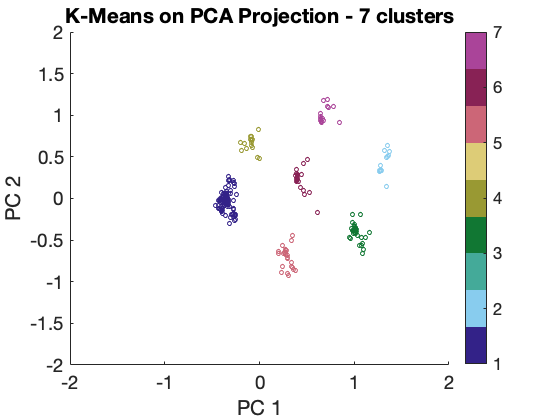

In [164]:
%K-means on PC Data
cluster_num = find(s_score == max(s_score));
[cluster_lbls,centroid_locs,sumd] = kmeans(PCA_allstim.score(:,1:2),cluster_num, 'Distance', 'sqeuclidean');
plot_PCA(PCA_allstim.score, cluster_lbls, 'K-Means on PCA Projection - 7 clusters')

cmap = ptc12(9);
colormap(cmap(1:9,:))
set(gca,'FontSize', 14)


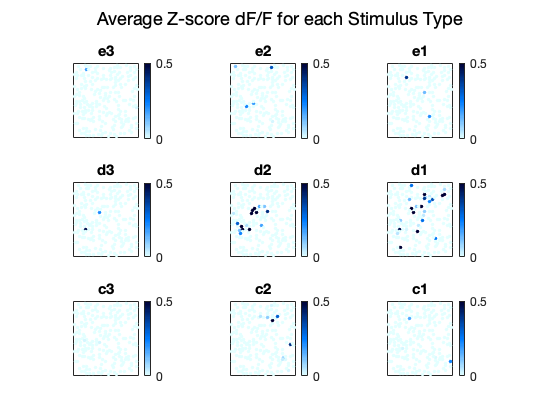

In [200]:
for stim = 1:length(stimulus)-1
    subplot(3,3,stim)
    plot_clusteronROIS(x_pst, y_pst, ROI_maxdff4stim_norm(:,stim), stimulus{stim},8)
end
sgtitle('Average Z-score dF/F for each Stimulus Type')

In [61]:
% Look at spatial cluster constituents
spatial_clusters{4}.rois
spatial_clusters{3}.rois
spatial_clusters{7}.rois
spatial_clusters{6}.rois

sim_indx = zeros(7);
sim_indx(2,3) = 4/9;
sim_indx(3,2) = 4/7;
sim_indx(2,6) = 2/9;
sim_indx(6,2) = 2/3;
sim_indx(2,7) = 6/9;
sim_indx(7,2) = 6/11;
sim_indx(3,6) = 1/7;
sim_indx(6,3) = 1/3;
sim_indx(3,7) = 2/7;
sim_indx(7,3) = 2/11;
sim_indx(6,7) = 2/3;
sim_indx(7,6) = 2/11;
sim_indx(1,1) = 1;
sim_indx(2,2) = 1;
sim_indx(3,3) = 1;
sim_indx(3,3) = 1;
sim_indx(4,4) = 1;
sim_indx(5,5) = 1;
sim_indx(6,6) = 1;
sim_indx(7,7) = 1;

heatmap(sim_indx);
xlabel('Cluster')
ylabel('Cluster')
% title('Similarity between Ensembles')
set(gca,'FontSize', 14)


ans =

    51
    52
    78
    79
    86
   120
   182
   190
   211


ans =

    79
   120
   123
   149
   182
   190
   207


ans =

    51
    79
   164


ans =

    14
    51
    52
    59
    78
    79
   151
   182
   188
   211
   212



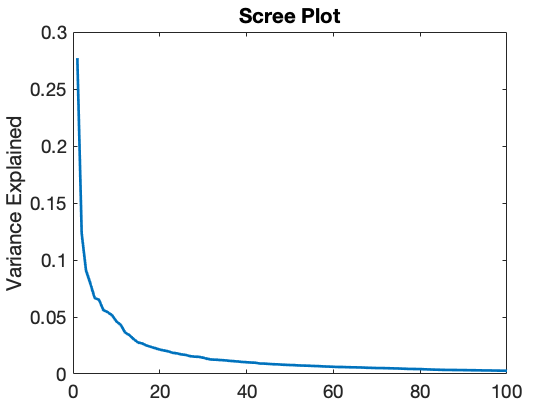

In [93]:
plot(PCA_allstim.latent, 'Linewidth', 2)
ylabel('Variance Explained')
xlim([0,100])
title('Scree Plot')
set(gca,'FontSize', 14)

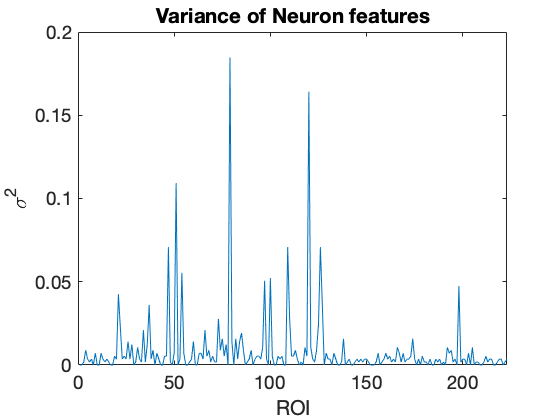

In [124]:
plot(var(stim_PA))
xlim([0,223])
set(gca,'FontSize', 14)
xlabel('ROI')
ylabel('\sigma^2')
title('Variance of Neuron features')

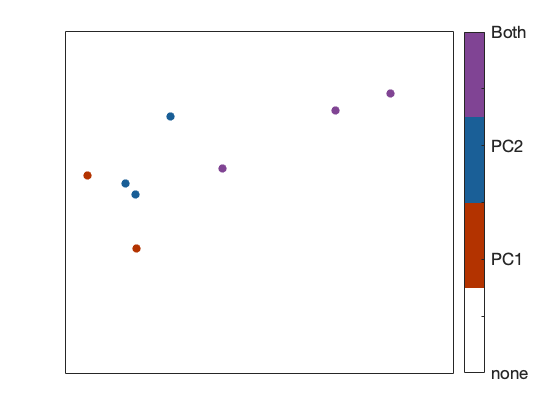

In [83]:
% PC weight analysis 

PC_weights{1}.rois;
PC1 = zeros(num_rois,1);
PC1(PC_weights{1}.rois) = 1;

PC_weights{2}.rois;
PC2 = zeros(num_rois,1);
PC2(PC_weights{2}.rois) = 2;

PClabel = PC1+PC2;

scatter(x_pst, y_pst, 40, PClabel, 'filled')
cmap_ROIS = [1,1,1;
            0.702,0.200,0.000;
            0.100,0.371,0.592;
            0.502,0.267,0.580];
xlim([0,513])
ylim([0,513])
set(gca,'xtick',[])
set(gca,'ytick',[])
box on

colormap(cmap_ROIS)
legend_PC = {'none', '','PC1','', 'PC2','', 'Both'};
colorbar('TickLabels', legend_PC)
set(gca,'FontSize', 14)